In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import torch
import lightning.pytorch as pl
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('husl'),)

from conf import conf
from dafm import datasets, models, utils

In [3]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [4]:
with hydra.initialize(version_base=utils.HYDRA_INIT['version_base'], config_path='../conf'):
    cfg = hydra.compose(utils.HYDRA_INIT['config_name'], overrides=[
        'model=FlowMatching', 'dataset=DoubleWell',
    ])
    engine = conf.get_engine()
    conf.orm.create_all(engine)
    with conf.sa.orm.Session(engine) as db:
        cfg = conf.orm.instantiate_and_insert_config(db, OmegaConf.to_container(cfg, resolve=True))
        pprint.pp(cfg)

Conf(root_dir='/root/workspace/GitHub/Data-Assimilation-Flow-Matching',
     out_dir='/root/workspace/out/dafm',
     run_subdir='runs',
     prediction_filename='trajectories.parquet',
     device='cuda',
     alt_id='7lv5eg5j',
     rng_seed=2376999025,
     fit=True,
     id=57,
     dataset=DoubleWell(predicted_state_count=1000,
                        time_step_count=100,
                        time_step_count_drop_first=0,
                        time_step_size=0.1,
                        observe_every_n_time_steps=1,
                        observe=Full(id=1),
                        integrator=<Integrator.EULER_MARUYAMA: 2>,
                        state_perturbation=<StatePerturbation.BAO_ET_AL_DOUBLE_WELL: 2>,
                        id=19,
                        state_dimension=1,
                        model_std=0.2,
                        observation_std=0.1,
                        true_state_initial_condition_std=0.02,
                        predicted_state_initial

In [5]:
# pl.seed_everything(cfg.rng_seed)
# with pl.utilities.seed.isolate_rng():
dynamics = datasets.get_dynamics_dataset(cfg.dataset, cfg.device)

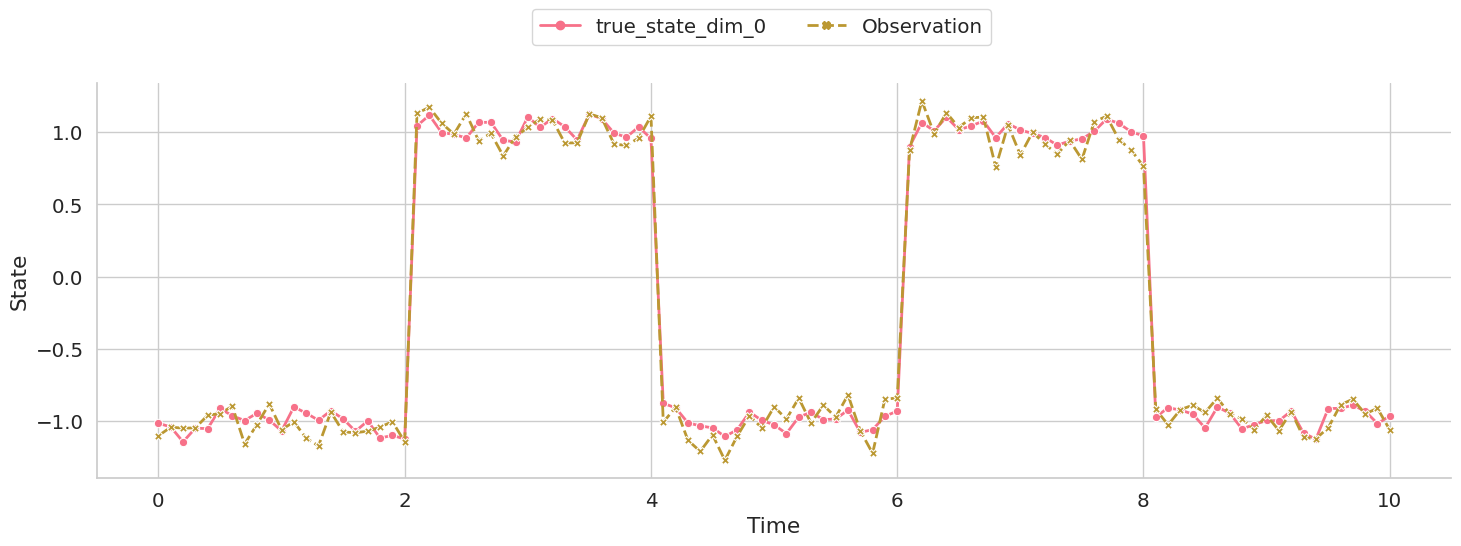

In [6]:
data = dynamics.data.copy()
data['true_state'] = rearrange(
    data['true_state'],
    't 1 dim -> t dim',
)
data['observation'] = rearrange(
    data['observation'],
    't 1 dim -> t dim',
)
data['true_state'] = pd.DataFrame(
    data['true_state'].cpu().numpy(),
    index=range(data['true_state'].shape[0]),
    columns=[f'true_state_dim_{d}' for d in range(dynamics.cfg.state_dimension)],
)
data['observation'] = pd.DataFrame(
    data['observation'].cpu().numpy(),
    index=range(data['observation'].shape[0]),
    columns=[f'observation_dim_{d}' for d in range(dynamics.cfg.state_dimension)],
)
data['times'] = pd.DataFrame(
    data['times'].cpu().numpy(),
    index=range(data['times'].shape[0]),
    columns=['Time'],
)
df = pd.concat([data[k] for k in ('times', 'true_state', 'observation')], axis=1)
dim = 0
df_line = pd.concat([
    data['times'],
    data['true_state'][f'true_state_dim_{dim}'],
    data['observation'][f'observation_dim_{dim}'].rename('Observation'),
], axis=1).melt(id_vars=['Time'], var_name='Source', value_name='State')
plot = (
    sns.relplot(
        data=df_line,
        kind='line',
        x='Time',
        y='State',
        hue='Source',
        style='Source',
        markers=True,
        aspect=3,
        linewidth=2,
        hue_order=['true_state_dim_0', 'Observation'],
    )
    # .set(ylim=(-1.5, 1.5))
)
sns.move_legend(
    plot,
    loc='upper center',
    ncol=min(len(df_line['Source'].unique()), 3),
    title='',
    bbox_to_anchor=(.455, 1.12),
    frameon=True,
    fancybox=True,
)